<a href="https://colab.research.google.com/github/guduru27s-design/LJEA-Project/blob/main/NCSSM_Tech_Lecture_3_Statistical_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

In [26]:
# Install package for diagnostic plots, later
!pip install lmdiag

In [27]:
import pandas as pd # Load the pandas module with the alias pd. Objects in this module can be referenced as pd.funciton()
import numpy as np
import matplotlib.pyplot as plt # I think this is to a submodule called pyplot
import seaborn as sns # another package for plotting
import random as rd # module for random value generation
import statsmodels.formula.api as smf
from scipy import stats
import statistics
import lmdiag

# Update default fontsize
plt.rcParams.update({'font.size': 18})

# Part 1 (code for figures)

## Nice Data

In [28]:
# Generate data for a simple 2-sample t-test

# Sample size
n = 500

# Set seed for random number generation
rd.seed(a = 90476)

# Generate random values from a normal (Gaussian) distribution
# with means at 1 and 3, respectively
values1 = [rd.gauss(mu=1, sigma=0.5) for x in range(n)]
values2 = [rd.gauss(mu=3, sigma=0.5) for x in range(n)]

# Transform into data frames
tb1 = {
  "observation": values1,
  "group": 1 # will repeat for length of values1
}
tb2 = {
  "observation": values2,
  "group": 2 # will repeat for length of values1
}

df1 = pd.DataFrame(tb1)
df2 = pd.DataFrame(tb2)

df = pd.concat([df1, df2])
print(df.head(5))
print(df.tail(5))

   observation  group
0     1.534939      1
1     1.924178      1
2     1.859205      1
3     1.026977      1
4     1.929019      1
     observation  group
495     2.722669      2
496     3.253092      2
497     3.023152      2
498     3.235615      2
499     2.740490      2


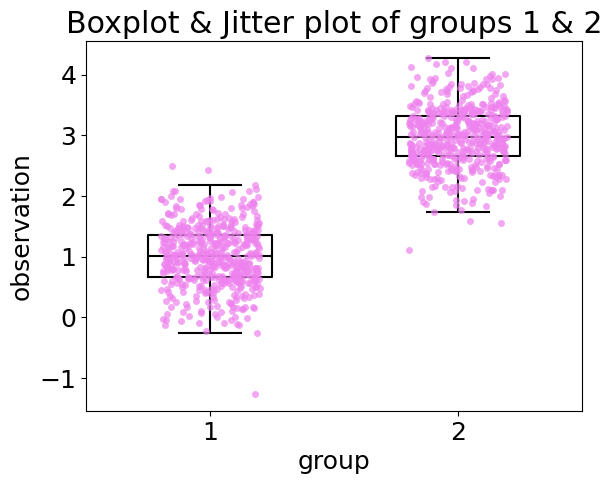

In [29]:
# @title
# Jitter plot to view the individual points
sns.stripplot(data =df, x = "group", y = "observation", jitter = 0.2,
              alpha = 0.7, color="violet", legend=False)

# Boxplot
sns.boxplot(data = df, x = "group", y = "observation",
            fliersize = 0, # plot outliers as size 0 (that is, hide outliers*)
            fill=False, color = "black", width=0.5)
# *Note that we can hide outliers because we are plotting every individual point,
# including outliers, with the jitter plot

# Add a title
plt.title("Boxplot & Jitter plot of groups 1 & 2")

# Save figure
plt.savefig("nice_data_2_groups.png", dpi = 300, bbox_inches="tight")

plt.show()

/tmp/ipykernel_3582/519186790.py:4: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.slr = pd.DataFrame({"x": x, "y": y})


Intercept    10.140839
x             0.498233
dtype: float64


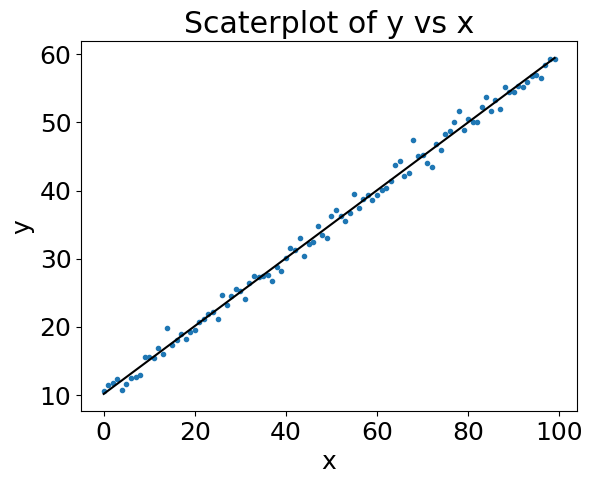

In [30]:
# Generate data for simple linear regression
x = [i for i in range(0, 100)]
y = [10 + 0.5*i + rd.gauss(mu=0,sigma=1) for i in range(0, 100)]
df.slr = pd.DataFrame({"x": x, "y": y})

# Fit a linear model
results = smf.ols('y ~ x', data = df.slr).fit()

# Extract the fitted intercept and slope to get the predicted values
print(results.params)
beta0_hat = results.params["Intercept"]
beta1_hat = results.params["x"]
y_hat = [beta0_hat + beta1_hat*i for i in range(0, 100)]
df.slr['y_hat'] = y_hat

plt.scatter(x, y, marker = ".")
plt.plot(x, y_hat, color = 'black')
plt.title("Scaterplot of y vs x")
plt.xlabel("x")
plt.ylabel("y")
plt.savefig("nice_data_slr.png", dpi = 300, bbox_inches="tight")
plt.show()

## Outliers

In [31]:
# Generate data for a simple 2-sample t-test

# Sample size
n = 50

# Set seed for random number generation
rd.seed(a = 9087)

# Generate random values with outliers manually added
values1 = [rd.gauss(mu=1, sigma=0.5) for x in range(n)]
values1.append(4)
values1.append(6)
values1.append(6.5)
values2 = [rd.gauss(mu=3, sigma=0.5) for x in range(n)]
values2.append(7)
values2.append(8)


# Transform into data frames
tb1 = {
  "observation": values1,
  "group": 1 # will repeat for length of values1
}
tb2 = {
  "observation": values2,
  "group": 2 # will repeat for length of values1
}

df1 = pd.DataFrame(tb1)
df2 = pd.DataFrame(tb2)

df = pd.concat([df1, df2])
print(df.head(5))
print(df.tail(5))

   observation  group
0     0.360243      1
1     0.607862      1
2     1.170173      1
3     1.172473      1
4     1.171886      1
    observation  group
47     2.735597      2
48     2.160713      2
49     1.752887      2
50     7.000000      2
51     8.000000      2


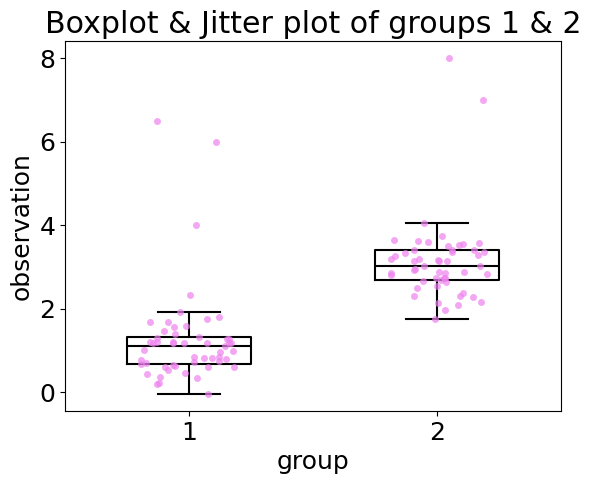

In [32]:
# @title
# Jitter plot to view the individual points
sns.stripplot(data =df, x = "group", y = "observation", jitter = 0.2,
              alpha = 0.7, color="violet", legend=False)

# Boxplot
sns.boxplot(data = df, x = "group", y = "observation",
            fliersize = 0, # plot outliers as size 0 (that is, hide outliers*)
            fill=False, color = "black", width=0.5)
# *Note that we can hide outliers because we are plotting every individual point,
# including outliers, with the jitter plot

# Add a title
plt.title("Boxplot & Jitter plot of groups 1 & 2")

# Save figure
plt.savefig("outliers.png", dpi = 300, bbox_inches="tight")

plt.show()

## Noisy & small sample

/tmp/ipykernel_3582/1082468443.py:4: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.slr = pd.DataFrame({"x": x, "y": y})


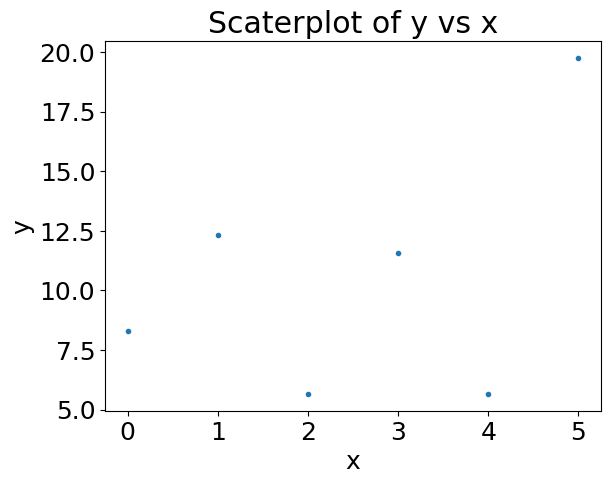

In [33]:
# Generate data for simple linear regression
x = [i for i in range(0, 6)]
y = [10 + 0.5*i + rd.gammavariate(alpha = 2, beta = 5) - 10 for i in range(0, 6)]
df.slr = pd.DataFrame({"x": x, "y": y})

plt.scatter(x, y, marker = ".")
plt.title("Scaterplot of y vs x")
plt.xlabel("x")
plt.ylabel("y")
plt.savefig("noisy_small_slr.png", dpi = 300, bbox_inches="tight")
plt.show()

## Statistical significance vs practical relevance

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     7.400
Date:                Mon, 15 Jun 2026   Prob (F-statistic):            0.00664
Time:                        14:57:06   Log-Likelihood:                -1806.8
No. Observations:                1000   AIC:                             3618.
Df Residuals:                     998   BIC:                             3627.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     10.0667      0.095    106.191      0.0

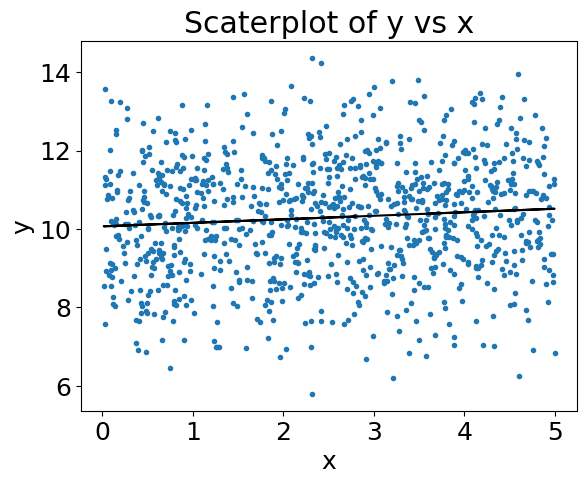

In [34]:
# Generate data for simple linear regression
rd.seed(876)
n = 1000
x = [rd.uniform(a = 0, b = 5) for i in range(0, n)]
y = [10 + 0.1*i + rd.gauss(mu = 0, sigma = 1.5) for i in x]
df.slr = pd.DataFrame({"x": x, "y": y})

# Fit a linear model
results = smf.ols('y ~ x', data = df.slr).fit()

# Extract the fitted intercept and slope to get the predicted values
print(results.summary())
beta0_hat = results.params["Intercept"]
beta1_hat = results.params["x"]
y_hat = [beta0_hat + beta1_hat*i for i in x]
df.slr['y_hat'] = y_hat

plt.scatter(x, y, marker = ".")
plt.plot(x, y_hat, color = 'black')
plt.title("Scaterplot of y vs x")
plt.xlabel("x")
plt.ylabel("y")
plt.savefig("sig_not_relevant_slr.png", dpi = 300, bbox_inches="tight")
plt.show()

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.166
Model:                            OLS   Adj. R-squared:                  0.102
Method:                 Least Squares   F-statistic:                     2.582
Date:                Mon, 15 Jun 2026   Prob (F-statistic):              0.132
Time:                        14:57:07   Log-Likelihood:                -23.645
No. Observations:                  15   AIC:                             51.29
Df Residuals:                      13   BIC:                             52.71
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     10.1482      0.690     14.702      0.0

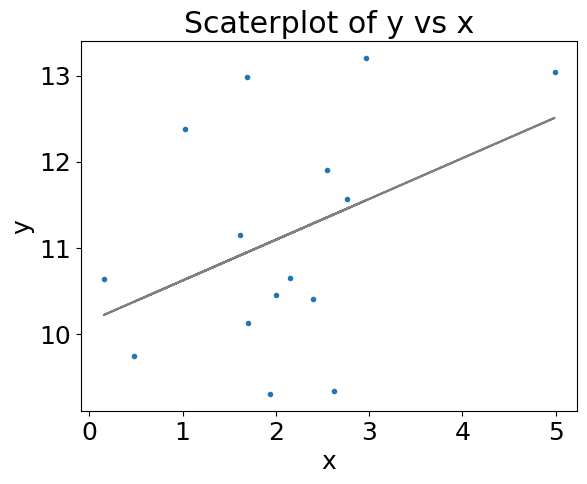

In [35]:
# Not statistically significance, but possibly practically relevant
n = 15
x = [rd.uniform(a = 0, b = 5) for i in range(0, n)]
y = [10 + 0.5*i + rd.gauss(mu = 0, sigma = 1) for i in x]
df.slr = pd.DataFrame({"x": x, "y": y})

# Fit a linear model
results = smf.ols('y ~ x', data = df.slr).fit()

# Extract the fitted intercept and slope to get the predicted values
print(results.summary())
beta0_hat = results.params["Intercept"]
beta1_hat = results.params["x"]
y_hat = [beta0_hat + beta1_hat*i for i in x]
df.slr['y_hat'] = y_hat

plt.scatter(x, y, marker = ".")
plt.plot(x, y_hat, color = 'grey')
plt.title("Scaterplot of y vs x")
plt.xlabel("x")
plt.ylabel("y")
plt.savefig("not_sig_is_relevant_slr.png", dpi = 300, bbox_inches="tight")
plt.show()

In [36]:
# Generate data for a simple 2-sample t-test

# Sample size
n = 50

# Set seed for random number generation
rd.seed(a = 9087)

# Generate random values with outliers manually added
values1 = [rd.gauss(mu=1, sigma=0.1) for x in range(n)]
values2 = [rd.gauss(mu=1.1, sigma=0.1) for x in range(n)]

# Transform into data frames
tb1 = {
  "observation": values1,
  "group": 1 # will repeat for length of values1
}
tb2 = {
  "observation": values2,
  "group": 2 # will repeat for length of values1
}

df1 = pd.DataFrame(tb1)
df2 = pd.DataFrame(tb2)

df = pd.concat([df1, df2])


# Conduct t-test
t_stat, p_val = stats.ttest_ind(values1, values2, equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")

T-statistic: -4.5405
P-value: 0.0000


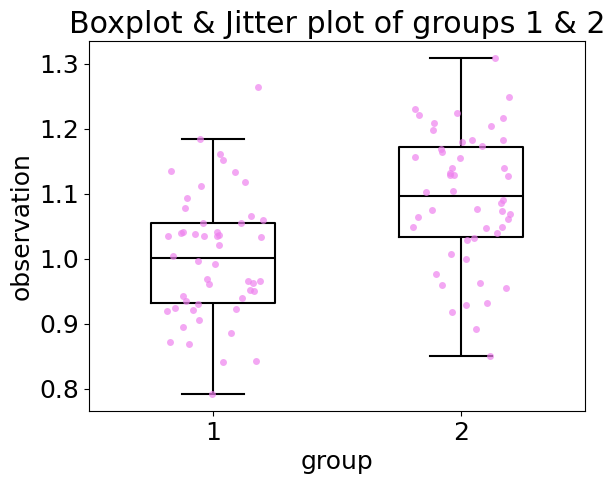

In [37]:
# Jitter plot to view the individual points
sns.stripplot(data =df, x = "group", y = "observation", jitter = 0.2,
              alpha = 0.7, color="violet", legend=False)

# Boxplot
sns.boxplot(data = df, x = "group", y = "observation",
            fliersize = 0, # plot outliers as size 0 (that is, hide outliers*)
            fill=False, color = "black", width=0.5)
# *Note that we can hide outliers because we are plotting every individual point,
# including outliers, with the jitter plot

# Add a title
plt.title("Boxplot & Jitter plot of groups 1 & 2")

# Save figure
plt.savefig("sig_not_relevant_ttest.png", dpi = 300, bbox_inches="tight")

plt.show()

# Part 2: Statistics with python

First, download the iris.csv file here: https://drive.google.com/file/d/1qszL-arZAsFhdNFy_y7aPw7-KIOiaYlO/view?usp=sharing

Then, back in your google collab notebook, navigate to "Files" then click the small up arrow to upload this file.

In [38]:
iris = pd.read_csv("iris.csv")
display(iris)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


The iris dataset contains:
* Rows = Flowers
* Columns = attributes of the flowers (species, petal length, etc)

In [39]:
# Note number of observations per species
iris.groupby('Species').size().reset_index(name='number_per_species')

,Species,number_per_species
0,setosa,50
1,versicolor,50
2,virginica,50


# T-test

## Example

Say we want to compare the mean petal lengths of Versicolor and Virginia flowers.

Assumptions to check to run the t-test
1. The two samples are independent
2. Observations within each group:
  * Are independent
  * Have the same true population mean
  * Have the same true population variance
  * Are (approximately) normally distributed

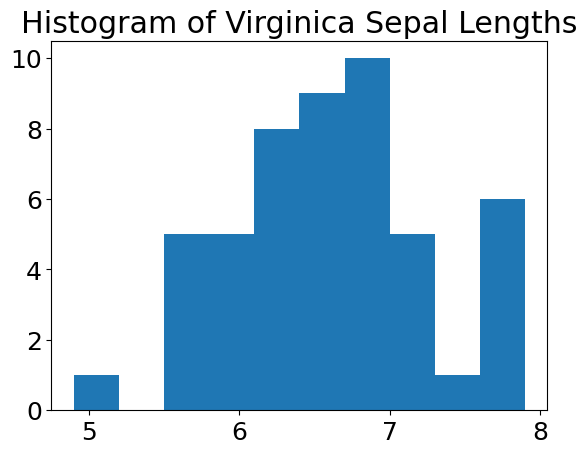

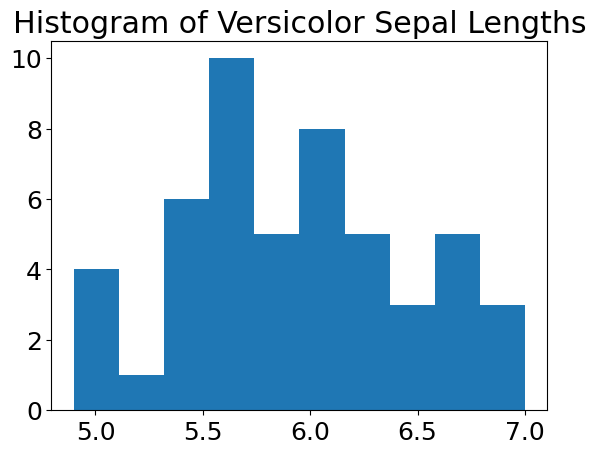

In [40]:
# Extract Petal widths for each species as a separate list
sepal_lengths_viriginica = iris.loc[iris['Species'] == 'virginica']['Sepal.Length']
sepal_lengths_versicolor = iris.loc[iris['Species'] == 'versicolor']['Sepal.Length']

# Histograms to assess normality
plt.hist(sepal_lengths_viriginica)
plt.title("Histogram of Virginica Sepal Lengths")
plt.show()

plt.hist(sepal_lengths_versicolor)
plt.title("Histogram of Versicolor Sepal Lengths")
plt.show()

Normality is a bit difficult to assess, but there are no eggregious outliers and the distributions are roughly peaked in the middle and not clearly skewed. Furthermore, the sample sizes are decently large (50 per species), so the sample mean will be getting closer to normality regardless due to the Central Limit Theorem. So, I think approximate normality is justifiable to assume in this case.

In [41]:
# Conduct the test
result = stats.ttest_ind(a = sepal_lengths_viriginica,
                        b = sepal_lengths_versicolor,
                        equal_var=False,           # Assuming unequal variances to play it safe
                        alternative = 'two-sided')
#print(vars(result))

# Display test statistic, degrees of freedom, and p-value
print(f"T statistic: {result.statistic:.4f}")
print(f"Degrees of freedom: {result.df:.4f}")
print(f"P-value: {result.pvalue:.4f}")
conf_int = result.confidence_interval(confidence_level=0.95)
print(f"95% Confidence Interval: ({conf_int[0]:.4f}, {conf_int[1]:.4f})")


T statistic: 5.6292
Degrees of freedom: 94.0255
P-value: 0.0000
95% Confidence Interval: (0.4220, 0.8820)


## Try-it-yourself
Conduct a two-sample t-test to compare the mean **petal** lengths for 2 of the flower species.

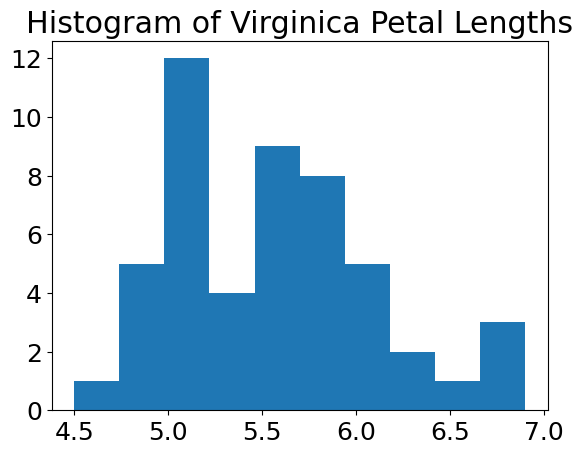

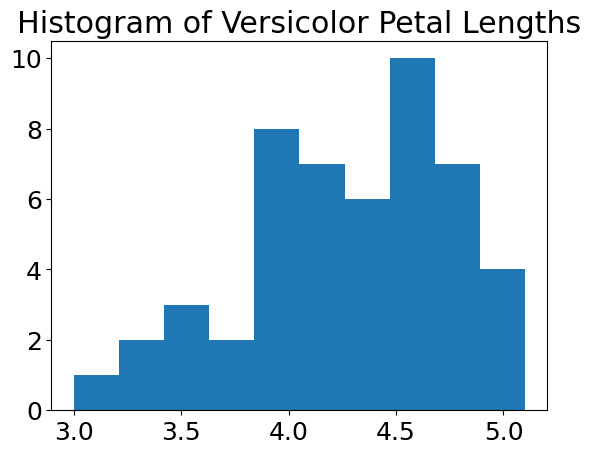

T statistic: 12.6038
Degrees of freedom: 95.5704
P-value: 0.0000
95% Confidence Interval: (1.0885, 1.4955)


In [42]:
# Histograms to inspect normality
petal_lengths_viriginica = iris.loc[iris['Species'] == 'virginica']['Petal.Length']
petal_lengths_versicolor = iris.loc[iris['Species'] == 'versicolor']['Petal.Length']

# Histograms to assess normality
plt.hist(petal_lengths_viriginica)
plt.title("Histogram of Virginica Petal Lengths")
plt.show()

plt.hist(petal_lengths_versicolor)
plt.title("Histogram of Versicolor Petal Lengths")
plt.show()

# T-test and show results
result = stats.ttest_ind(a = petal_lengths_viriginica,
                        b = petal_lengths_versicolor,
                        equal_var=False,           # Assuming unequal variances to play it safe
                        alternative = 'two-sided')
#print(vars(result))

# Display test statistic, degrees of freedom, and p-value
print(f"T statistic: {result.statistic:.4f}")
print(f"Degrees of freedom: {result.df:.4f}")
print(f"P-value: {result.pvalue:.4f}")
conf_int = result.confidence_interval(confidence_level=0.95)
print(f"95% Confidence Interval: ({conf_int[0]:.4f}, {conf_int[1]:.4f})")

## Follow-up
Question: Would it be reasonable to use equal.var=True? Would that impact the results?

In [43]:
# Calculate sample standard deviation of each group
print(f"Virginica Sepal Length sample sd: {statistics.stdev(sepal_lengths_viriginica):.4f}")
print(f"Versicolor Sepal Length sample sd: {statistics.stdev(sepal_lengths_versicolor):.4f}")

Virginica Sepal Length sample sd: 0.6359
Versicolor Sepal Length sample sd: 0.5162


Given that the sample standard deviations are similar (differ by less than 0.1, which is small compared to the scale of typical sepal length values), I think we could use the equal.var=True setting.

In [44]:
# Conduct the test
result = stats.ttest_ind(a = sepal_lengths_viriginica,
                        b = sepal_lengths_versicolor,
                        equal_var=True,
                        alternative = 'two-sided')
#print(vars(result))

# Display test statistic, degrees of freedom, and p-value
print(f"T statistic: {result.statistic:.4f}")
print(f"Degrees of freedom: {result.df:.4f}")
print(f"P-value: {result.pvalue:.4f}")
conf_int = result.confidence_interval(confidence_level=0.95)
print(f"95% Confidence Interval: ({conf_int[0]:.4f}, {conf_int[1]:.4f})")

T statistic: 5.6292
Degrees of freedom: 98.0000
P-value: 0.0000
95% Confidence Interval: (0.4221, 0.8819)


# Linear regression

## Example

Say we know what to impact the relationship between Sepal width and Sepal length

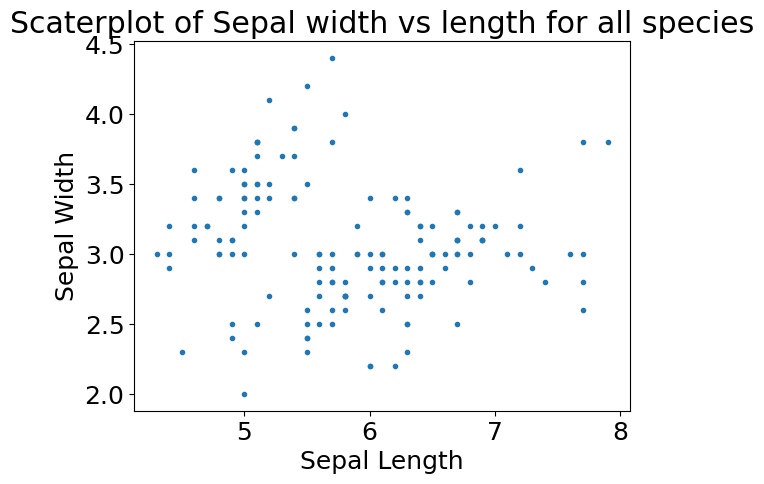

In [45]:
# Graph
plt.scatter(iris['Sepal.Length'], iris['Sepal.Width'], marker = ".")
plt.title("Scaterplot of Sepal width vs length for all species")
plt.ylabel("Sepal Width")
plt.xlabel("Sepal Length")
plt.show()

Linear relationship is not clear, but will try fitting a model for the sake of example.

Will fit linear model of the form:

Sepal_Width = b0 + b1*Sepal_Length + e

(where b0 is the intercept, b1 is the slope, and e is the random error).

In [46]:
sepal_model = smf.ols('Sepal_Width ~ Sepal_Length', data = iris).fit()
print(sepal_model.summary())

PatsyError: Number of rows mismatch between data argument and Sepal_Width (150 versus 1)
    Sepal_Width ~ Sepal_Length
    ^^^^^^^^^^^

Parsing first chunk of output:

* OLS = Ordinary Least Squares (method used to obtain coefficient estimates)
* R-squared = rougly the percent of variance in the dependent variable explained by the model (in this case, by a linear relationship with the independent variable)
* Adjusted R-squared = adjusted version that takes into account the number of terms in the model (more on this later)
* AIC and BIC = measures of the quality of model fit. Difficult to judge on their own; best for comparing models. Smaller is better.

Second chunk:

* coef = Coefficient estimates for b0 and b1 !
* std err = standard error (of the estimates for b0 and b1)
* t = t-statistic for testing H_0: b0=0 or H_0: b1=0
* P>|t| = p-value corresponding to above test
* [#, #] = confidence intervals for b0 and b1

**Takeaways**
* This model seems poor (R-squared is very small, b1 estimate is very small and p-value is big)
* Not surprising, given the scatterplot

In [ ]:
# Plot model fit

# Extract the fitted intercept and slope to get the predicted values
beta0_hat = sepal_model.params["Intercept"]
beta1_hat = sepal_model.params["Sepal_Length"]
y_hat = [beta0_hat + beta1_hat*i for i in iris['Sepal_Length']]
iris['Sepal_Width_predicted'] = y_hat
#iris['Sepal_Width_predicted_test'] = sepal_model.fittedvalues # shortcut alternative approach

plt.scatter(iris['Sepal_Length'], iris['Sepal_Width'], marker = ".")
plt.plot(iris['Sepal_Length'], iris['Sepal_Width_predicted'], color = "gray")
plt.title("Scaterplot of Sepal width vs length for all species")
plt.ylabel("Sepal Width")
plt.xlabel("Sepal Length")
plt.show()


Thought: What if we consider each of the species separately?

In [ ]:
# Graph
p = sns.scatterplot(data = iris, x = 'Sepal_Length', y = 'Sepal_Width', hue=iris['Species'])
plt.title("Scaterplot of Sepal width vs length for all species")
plt.ylabel("Sepal Width")
plt.xlabel("Sepal Length")

# Move the legend to the right side
sns.move_legend(p, "upper left", bbox_to_anchor = (1,1))

plt.show()

Seems like the relationship for setosa is notably different than for the other two.

What if we alter our model?

Sepal_Width = b0 + b1\*Species + b2\*Sepal_Length + b3\*Species\*Sepal_length + e


In [ ]:
sepal_model2 = smf.ols('Sepal_Width ~ Species + Sepal_Length + Species*Sepal_Length', data = iris).fit()
print(sepal_model2.summary())

Takeaways
* R-squared (percent of total variation explained) is much larger
* Adjusted R-squared is also much larger (i.e., the improvement in model fit seems to outweigh the increased model complexity)
* AIC and BIC are lower
* All coefficient estimates appear statistically significant [assuming normality and other assumptions are met]
* Note that 'setosa' is treated as a baseline category. Coefficients shown are relative to the baseline.

In [ ]:
# Extract fitted y values
# (could get each coefficient value and calculate, but there are a lot of coefficients
# so below is much faster)
iris['Sepal_Width_predicted2'] = sepal_model2.fittedvalues

# Graph
p = sns.scatterplot(data = iris, x = 'Sepal_Length', y = 'Sepal_Width', hue=iris['Species'])
sns.lineplot(data = iris, x = 'Sepal_Length', y = 'Sepal_Width_predicted2', hue='Species', legend=False)
plt.title("Scaterplot of Sepal width vs length for all species")
plt.ylabel("Sepal Width")
plt.xlabel("Sepal Length")

# Move the legend to the right side
sns.move_legend(p, "upper left", bbox_to_anchor = (1,1))

plt.show()

This looks much better!

## Try-it-yourself

Try to fit a linear model of Petal Width versus Petal Length.
First fit with all of the data, then separate by Species. Does it make a difference?

In [ ]:
#

## Exercise Code

In [ ]:
# @title
petal_model = smf.ols('Petal_Width ~ Petal_Length', data = iris).fit()
print("\n\nModel 1 ------------------------------------")
print(petal_model.summary())

petal_model2 = smf.ols('Petal_Width ~ Petal_Length + Species + Species*Petal_Length', data = iris).fit()
print("\n\nModel 2 ------------------------------------")
print(petal_model2.summary())

Takeaways
* R-squared of the first model is very high!
* R-squared of the second model is a bit higher, but not that drastic
* Note how the adjusted R-squared is smaller for model 2, reflecting the model complexity
* AIC, BIC are lower with model 2
* p-values for slope coefficients (associated with Petal_Length) are all high - possibly all species could share the same slope coefficient
* p-value for at least one intercept coefficient is low - perhaps species-specific intercepts are merited

In [ ]:
# @title
petal_model3 = smf.ols('Petal_Width ~ Petal_Length + Species', data = iris).fit()
print("\n\nModel 3 ------------------------------------")
print(petal_model3.summary())

In [ ]:
# @title
iris['Petal_Width_predicted'] = petal_model.fittedvalues
iris['Petal_Width_predicted2'] = petal_model2.fittedvalues
iris['Petal_Width_predicted3'] = petal_model3.fittedvalues

# Graph
p = sns.scatterplot(data = iris, x = 'Petal_Length', y = 'Petal_Width', hue=iris['Species'])
sns.lineplot(data = iris, x = 'Petal_Length', y = 'Petal_Width_predicted', color='gray', legend=False)
sns.lineplot(data = iris, x = 'Petal_Length', y = 'Petal_Width_predicted2', hue='Species', legend=False)
sns.lineplot(data = iris, x = 'Petal_Length', y = 'Petal_Width_predicted3', hue='Species', legend=False, linestyle='--')
plt.title("Scaterplot of Petal width vs length for all species")
plt.ylabel("Petal Width")
plt.xlabel("Petal Length")

# Move the legend to the right side
sns.move_legend(p, "upper left", bbox_to_anchor = (1,1))

plt.show()

Conclusion: Probably all three of these models are justifiable.

## Bonus

You can use the same code to fit even models with non-linear relationships!

In [ ]:
sepal_model3 = smf.ols('Sepal_Width ~ Sepal_Length + I(Sepal_Length^2)', data = iris).fit()
print(sepal_model3.summary())

In [ ]:
# Diagnostic plots

sepal_model = smf.ols('Sepal_Width ~ Sepal_Length', data = iris).fit()
fig = lmdiag.plot(sepal_model)
fig.show()